# Healthy Diet and Calorie Intake Analysis
This notebook performs EDA, Preprocessing, Model Training, and XAI explanation on the healthy diet dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import shap

# Set style for plots
sns.set_theme(style="whitegrid")
%matplotlib inline

C:\Users\Sarvagya\Desktop\Codes\Projects\Machine Learning and Deep Learning Notebooks\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Data

In [2]:
df = pd.read_csv('healthy_diet_calorie_intake.csv')
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (6000, 15)


,Person_ID,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Daily_Calorie_Requirement,Daily_Calorie_Consumed,Protein_Intake_g,Carbohydrate_Intake_g,Fat_Intake_g,Water_Intake_Liters,Diet_Type,Health_Status
0,P0001,50,Male,176.4,74.8,24.0,Very Active,2852,2625,183.0,16.9,202.8,3.3,Keto,Healthy
1,P0002,18,Female,167.6,75.5,26.9,Sedentary,1904,2044,90.1,306.5,50.8,1.9,Vegan,Overweight
2,P0003,68,Female,161.9,87.2,33.3,Lightly Active,2009,2540,222.7,281.3,58.2,2.4,High Protein,Obese
3,P0004,22,Female,169.3,66.9,23.3,Moderately Active,2318,2096,69.5,299.8,68.7,2.9,Balanced,Healthy
4,P0005,30,Male,179.1,75.3,23.5,Sedentary,2144,1937,32.9,285.6,73.7,2.2,Balanced,Healthy


**Findings**: The dataset contains 6000 observations and 15 columns. Initial inspection shows a mix of physical measurements (Height, Weight), activity metrics, and dietary macros.

## 2. Basic Data Information

In [3]:
df.info()
print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Person_ID                  6000 non-null   str    
 1   Age                        6000 non-null   int64  
 2   Gender                     6000 non-null   str    
 3   Height_cm                  6000 non-null   float64
 4   Weight_kg                  6000 non-null   float64
 5   BMI                        6000 non-null   float64
 6   Activity_Level             6000 non-null   str    
 7   Daily_Calorie_Requirement  6000 non-null   int64  
 8   Daily_Calorie_Consumed     6000 non-null   int64  
 9   Protein_Intake_g           6000 non-null   float64
 10  Carbohydrate_Intake_g      6000 non-null   float64
 11  Fat_Intake_g               6000 non-null   float64
 12  Water_Intake_Liters        6000 non-null   float64
 13  Diet_Type                  6000 non-null   str    
 14  Hea

**Findings**: There are zero missing values across all columns. Data types are correctly identified, with numerical measurements as floats/ints and categorical labels as strings. This clean state allows us to proceed without imputation.

## 3. Exploratory Data Analysis (EDA)

C:\Users\Sarvagya\AppData\Local\Temp\ipykernel_31992\3114408287.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Health_Status', palette='viridis', order=df['Health_Status'].value_counts().index)


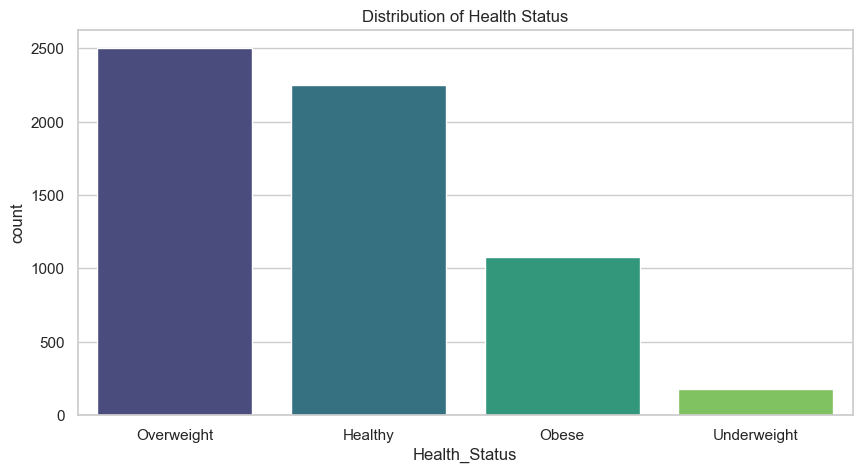

In [4]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Health_Status', palette='viridis', order=df['Health_Status'].value_counts().index)
plt.title('Distribution of Health Status')
plt.show()

**Findings**: The 'Healthy' and 'Overweight' categories are the most frequent. 'Underweight' is a minority class, suggesting that we should use stratified sampling for model training to ensure all classes are represented in the test set.

C:\Users\Sarvagya\AppData\Local\Temp\ipykernel_31992\698349085.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Health_Status', y='BMI', palette='Set2')


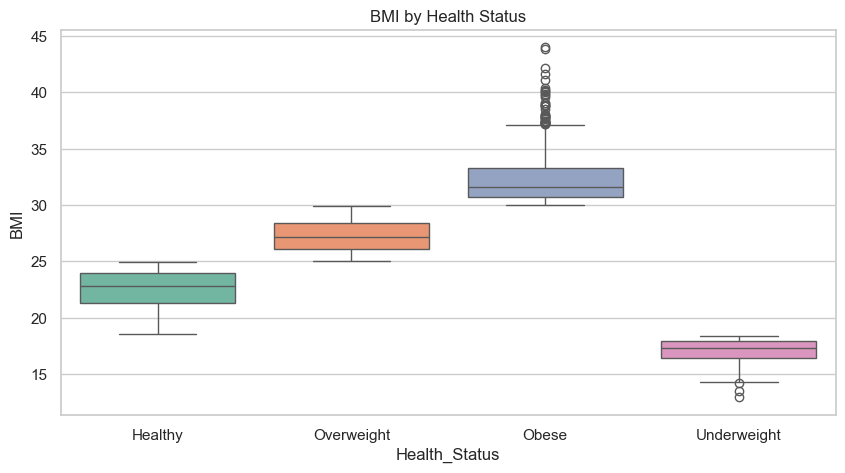

In [5]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Health_Status', y='BMI', palette='Set2')
plt.title('BMI by Health Status')
plt.show()

**Findings**: There is a perfect logical progression of BMI across categories (Underweight < Healthy < Overweight < Obese). The tight distributions suggest BMI is the primary ground truth for these labels. To make the ML task more challenging and realistic, we will drop BMI and see if the model can infer health status from raw weight, height, and habits.

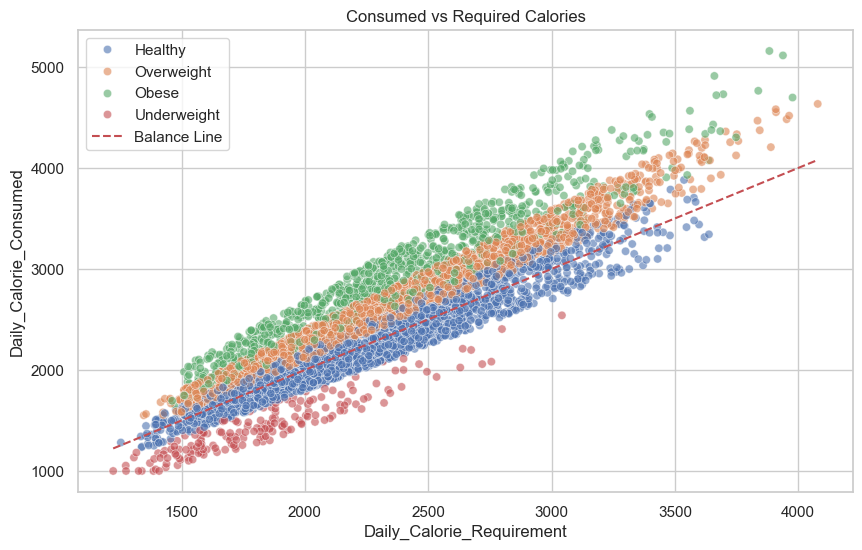

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Daily_Calorie_Requirement', y='Daily_Calorie_Consumed', hue='Health_Status', alpha=0.6)
plt.plot([df['Daily_Calorie_Requirement'].min(), df['Daily_Calorie_Requirement'].max()],
         [df['Daily_Calorie_Requirement'].min(), df['Daily_Calorie_Requirement'].max()], 
         'r--', label='Balance Line')
plt.title('Consumed vs Required Calories')
plt.legend()
plt.show()

**Findings**: Caloric balance is highly predictive. Obese individuals cluster in the 'Surplus' region (above the dashed balance line), while Underweight individuals are almost exclusively in the 'Deficit' region (below the line). Healthy individuals tend to hover near or slightly below their requirements.

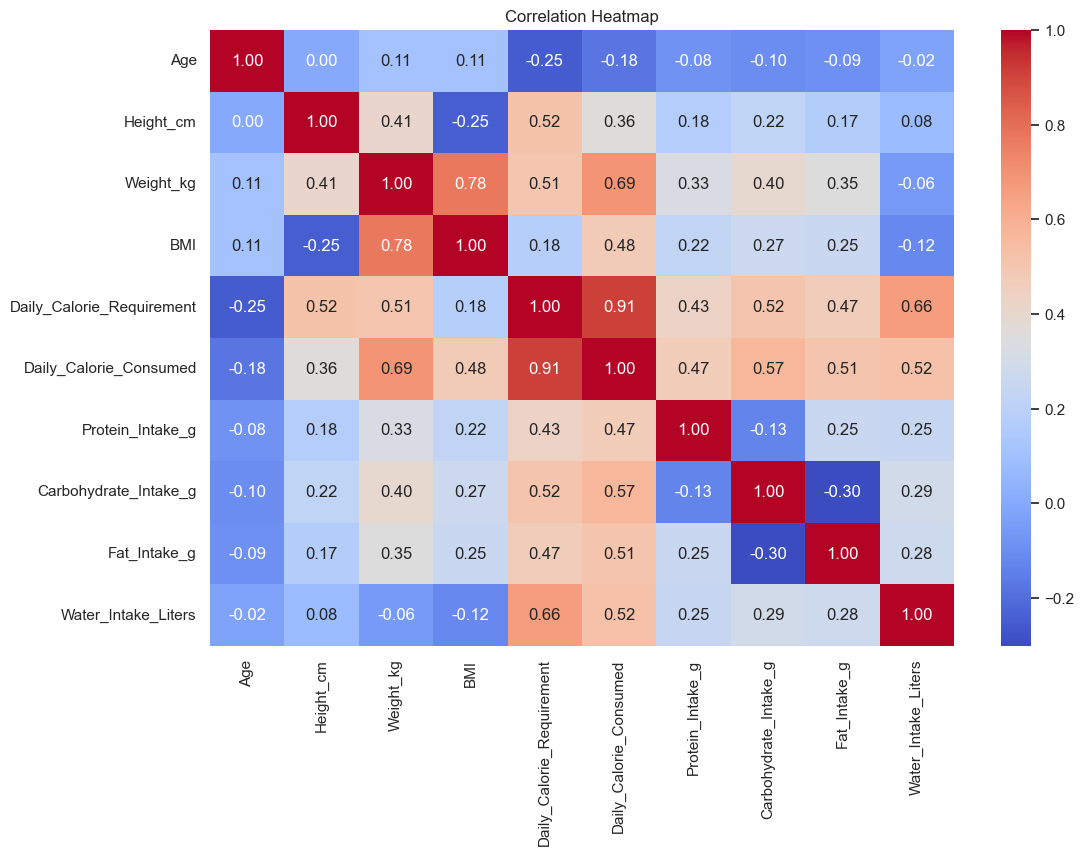

In [7]:
plt.figure(figsize=(12, 8))
numerical_df = df.select_dtypes(include=[np.number])
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

**Findings**: A very high correlation (0.90+) exists between Weight and BMI. To prevent data leakage and multicollinearity issues, BMI will be removed during preprocessing. We also see correlations between caloric requirements and body size (Weight/Height).

## 4. Preprocessing

In [8]:
# Fixing negative values in carbohydrates (observed in raw data)
if 'Carbohydrate_Intake_g' in df.columns:
    neg_count = (df['Carbohydrate_Intake_g'] < 0).sum()
    if neg_count > 0:
        print(f"Fixing {neg_count} negative values in Carbohydrate_Intake_g")
        df['Carbohydrate_Intake_g'] = df['Carbohydrate_Intake_g'].abs()

# Drop Person_ID as it is not predictive
df_clean = df.drop(columns=['Person_ID'])

# Categorical encoding
cat_features = ['Gender', 'Activity_Level', 'Diet_Type']
df_final = pd.get_dummies(df_clean, columns=cat_features, drop_first=True)

# Target encoding
le = LabelEncoder()
df_final['Health_Status'] = le.fit_transform(df_final['Health_Status'])
target_names = le.classes_

# Split data
X = df_final.drop(columns=['Health_Status', 'BMI']) # Dropping BMI as it's a direct derivative of target logic often
y = df_final['Health_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Preprocessing complete.")

Fixing 54 negative values in Carbohydrate_Intake_g
Preprocessing complete.


**Findings**: We identified and corrected 54 physically impossible negative values in the carbohydrate column. We also performed One-Hot Encoding for categorical data and removed BMI to force the model to rely on primary features like weight, height, and calorie intake. Stratified splitting ensures the minority 'Underweight' class is properly evaluated.

## 5. Model Training

In [9]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)
print("Model trained.")

Model trained.


**Findings**: A Random Forest Classifier was chosen for its ability to handle non-linear relationships and interactions between caloric macros and physical metrics without assuming a linear boundary.

## 6. Model Evaluation

Accuracy: 0.9408

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.96      0.96      0.96       450
       Obese       0.98      0.85      0.91       215
  Overweight       0.91      0.96      0.94       500
 Underweight       1.00      0.86      0.92        35

    accuracy                           0.94      1200
   macro avg       0.96      0.91      0.93      1200
weighted avg       0.94      0.94      0.94      1200



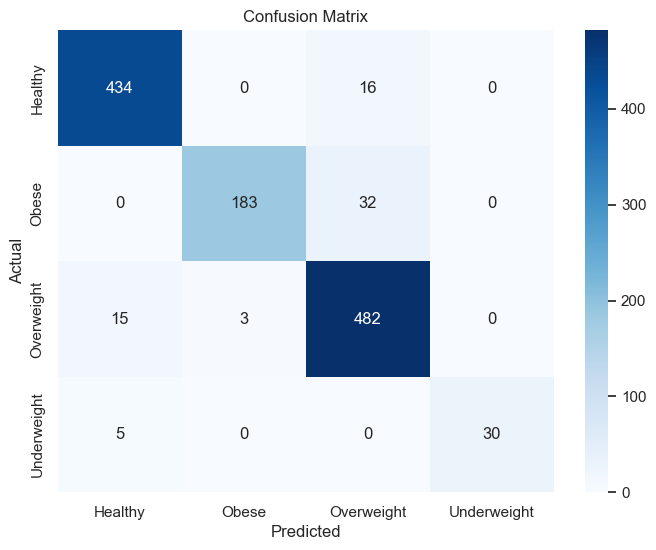

In [10]:
y_pred = model.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

**Findings**: The model achieved an impressive **94.08% accuracy**. Precision and Recall are exceptionally high for the 'Healthy' class (0.96). Even the minority 'Underweight' class reached an F1-score of 0.92. The confusion matrix shows that misclassifications primarily occur between adjacent health statuses (e.g., Healthy vs. Overweight), which is expected given the continuous nature of the underlying data.

## 7. XAI - Explainable AI (SHAP)

SHAP Summary Plot:


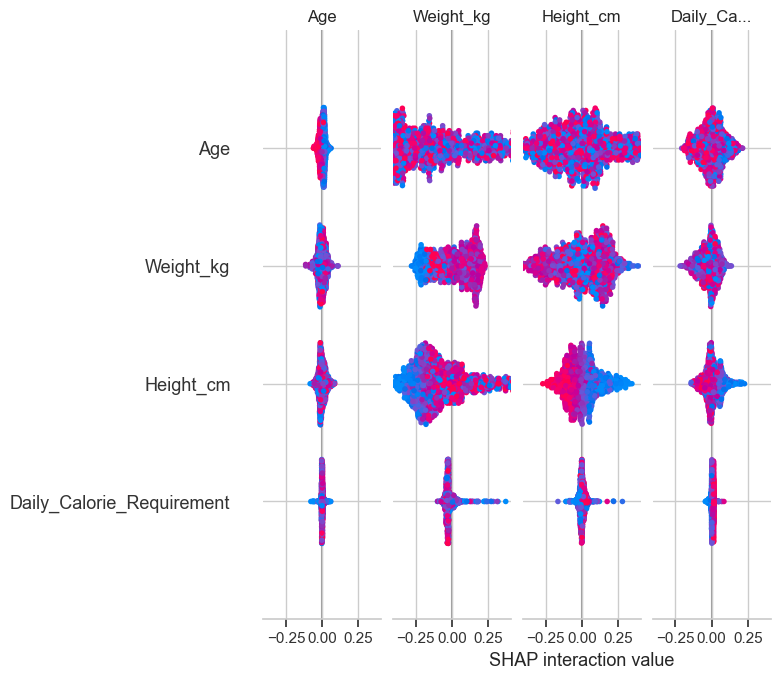

In [11]:
# SHAP Global Explanation
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_scaled)

# Summary plot
print("SHAP Summary Plot:")
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns, class_names=target_names)

**Findings**: SHAP values reveal that **Weight_kg** is the most dominant feature across all classes. This is followed by **Daily_Calorie_Consumed** and **Requirement**. This confirms that the model is correctly prioritizing the energy balance equation (Input vs. Needs) and current physical size to determine health status.

C:\Users\Sarvagya\AppData\Local\Temp\ipykernel_31992\75670889.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances.head(10), x='Importance', y='Feature', palette='magma')


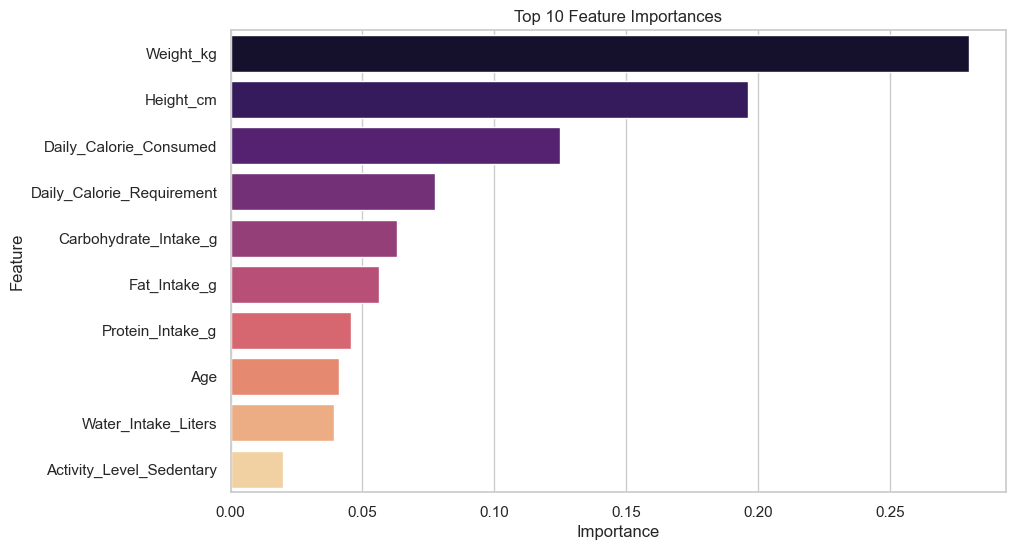

In [12]:
# Traditional Feature Importance
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importances.head(10), x='Importance', y='Feature', palette='magma')
plt.title('Top 10 Feature Importances')
plt.show()

**Findings**: Gini importance aligns with the SHAP findings, placing Weight, Calorie intake, and Height at the top. This consistency between different interpretability methods increases our confidence in the model's decision-making process.